## **Price Analysis**

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/raw/car_details.csv')

### **Missing Values**

**Plan**: Definitely dropping nans since price is my target feature

---

In [3]:
database_length = len(df)
price_missing_count = df['price'].isna().sum()

basic_info_df = pd.DataFrame({
    'Total Cars': [database_length],
    'Missing Price': [price_missing_count],
    'Missing Price %': [f'{(price_missing_count/database_length)*100:.2f}%'],
})

display(basic_info_df.style.hide(axis='index'))

Total Cars,Missing Price,Missing Price %
106447,1102,1.04%


### **Price Ranges**

- Exploring how many cars fall into different price ranges

- Looking to drop overly cheap and expensive cars


---


Range,Count,%
0 - 100k,62,0.06
100k - 200k,443,0.42
200k - 300k,1021,0.96
300k - 500k,3225,3.03
500k - 1M,8315,7.81
1M - 2M,16469,15.47
2M - 3M,13387,12.58
3M - 5M,17722,16.65
5M - 10M,21324,20.03
10M - 20M,16061,15.09


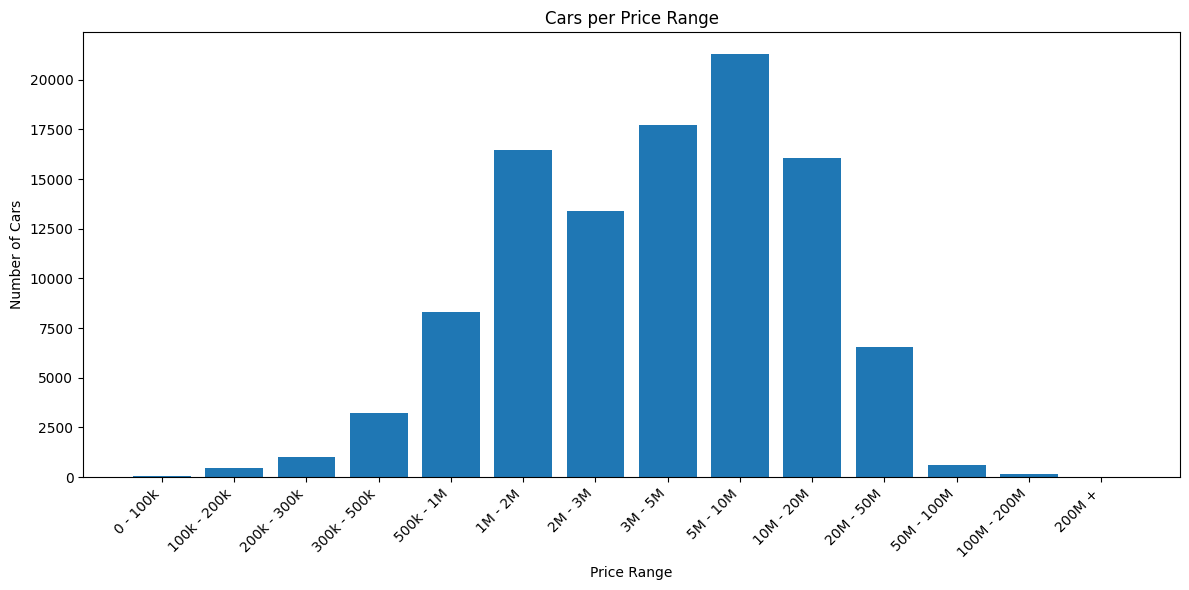

In [4]:
ranges = [
    (0, 100_000, "0 - 100k"),
    (100_000, 200_000, "100k - 200k"),
    (200_000, 300_000, "200k - 300k"),
    (300_000, 500_000, "300k - 500k"),
    (500_000, 1_000_000, "500k - 1M"),
    (1_000_000, 2_000_000, "1M - 2M"),
    (2_000_000, 3_000_000, "2M - 3M"),
    (3_000_000, 5_000_000, "3M - 5M"),
    (5_000_000, 10_000_000, "5M - 10M"),
    (10_000_000, 20_000_000, "10M - 20M"),
    (20_000_000, 50_000_000, "20M - 50M"),
    (50_000_000, 100_000_000, "50M - 100M"),
    (100_000_000, 200_000_000, "100M - 200M"),
    (200_000_000, float('inf'), "200M +")
]

data = []
for low, high, label in ranges:
    count = len(df[(df['price'] >= low) & (df['price'] < high)])
    percent = count / len(df) * 100
    data.append({
        'Range': label,
        'Count': count,
        '%': f'{percent:.2f}'
    })

price_ranges_df = pd.DataFrame(data)
display(price_ranges_df.style.hide(axis='index'))



plt.figure(figsize=(12,6))
plt.bar(price_ranges_df['Range'], price_ranges_df['Count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Price Range")
plt.ylabel("Number of Cars")
plt.title("Cars per Price Range")
plt.tight_layout()
plt.show()

### Outliers

**Findings:**
- Overly cheap & overly expensive cars exist
- Luxury cars seem legitimate but are hard to predict ~ very small sample size
- Extremely cheap cars often don’t make sense ~ and some are obvious errors and mistypings

**Plan:**
- Drop outliers
- Keeping cars in the range of **200K – 100M**

In [5]:
cars_under_200k_df = df[df['price'] <= 200_000].sort_values('price').head(30)
cars_over_100M_df = df[df['price'] >= 100_000_000].sort_values('price', ascending=False).head(30)

cars_under_200k_df = pd.DataFrame({
    'Price' : cars_under_200k_df['price'].values.astype(int),
    'Manufacturer' : cars_under_200k_df['manufacturer'].values,
    'Model' : cars_under_200k_df['model'].values,
    'Year' : cars_under_200k_df['year'].values,
    'kw' : cars_under_200k_df['kw'].values,

    '' : ' | ',
})

cars_over_100M_df = pd.DataFrame({
    '' : ' | ',
    'Price' : cars_over_100M_df['price'].values.astype(int),
    'Manufacturer' : cars_over_100M_df['manufacturer'].values,
    'Model' : cars_over_100M_df['model'].values,
    'Year' : cars_over_100M_df['year'].values,
    'kw' : cars_over_100M_df['kw'].values
})



combined = pd.concat(
    [cars_under_200k_df, cars_over_100M_df],
    axis=1
)
combined['Price'] = combined['Price'].map(lambda x: f"{int(x):,}".replace(",", " "))
for col in ["Year", "kw"]:
    combined[col] = combined[col].map(lambda x: f"{x:.2f}") 


pd.set_option("display.max_rows", None)
display(combined.style.hide(axis="index"))


Price,Manufacturer,Model,Year,kw,,,Price,Manufacturer,Model,Year,kw
1,PEUGEOT,305,1984.00,57.00,|,|,1 230 191 104,MCLAREN,P1,2016.25,735.00
3,OPEL,VIVARO,2010.92,66.00,|,|,359 999 999,MERCEDES-MAYBACH,EGYÉB,2021.42,463.00
1 000,AUDI,A4,2019.33,140.00,|,|,355 775 000,MERCEDES-AMG,G-OSZTÁLY G 63,2015.83,400.00
3 850,BMW,Z SOROZAT Z4,2003.42,141.00,|,|,330 200 000,FERRARI,SF90 SPIDER,2022.58,574.00
25 000,MERCEDES-BENZ,GLE-OSZTÁLY GLE 250,2016.17,150.00,|,|,268 500 000,LAMBORGHINI,REVUELTO,2024.00,747.00
50 000,RENAULT,CLIO,1993.92,57.00,|,|,252 000 000,FERRARI,SF90 SPIDER,2024.75,574.00
55 000,SUZUKI,SWIFT,1997.25,50.00,|,|,249 900 000,FERRARI,SF90 SPIDER,2023.33,736.00
60 000,FORD,KA,2003.00,50.00,|,|,246 500 000,FERRARI,SF90 SPIDER,2025.00,nan
65 000,PEUGEOT,206,2004.42,66.00,|,|,234 300 000,MERCEDES-AMG,G-OSZTÁLY G 63,2025.00,588.00
65 000,FORD,ESCORT,1998.50,66.00,|,|,234 300 000,MERCEDES-BENZ,G-OSZTÁLY G 63 AMG,2025.00,588.00


### **Log Transform**

- Price feature is really skewed

- Few really expensive cars, lot of cheap ones

**Plan**: Log transform for 

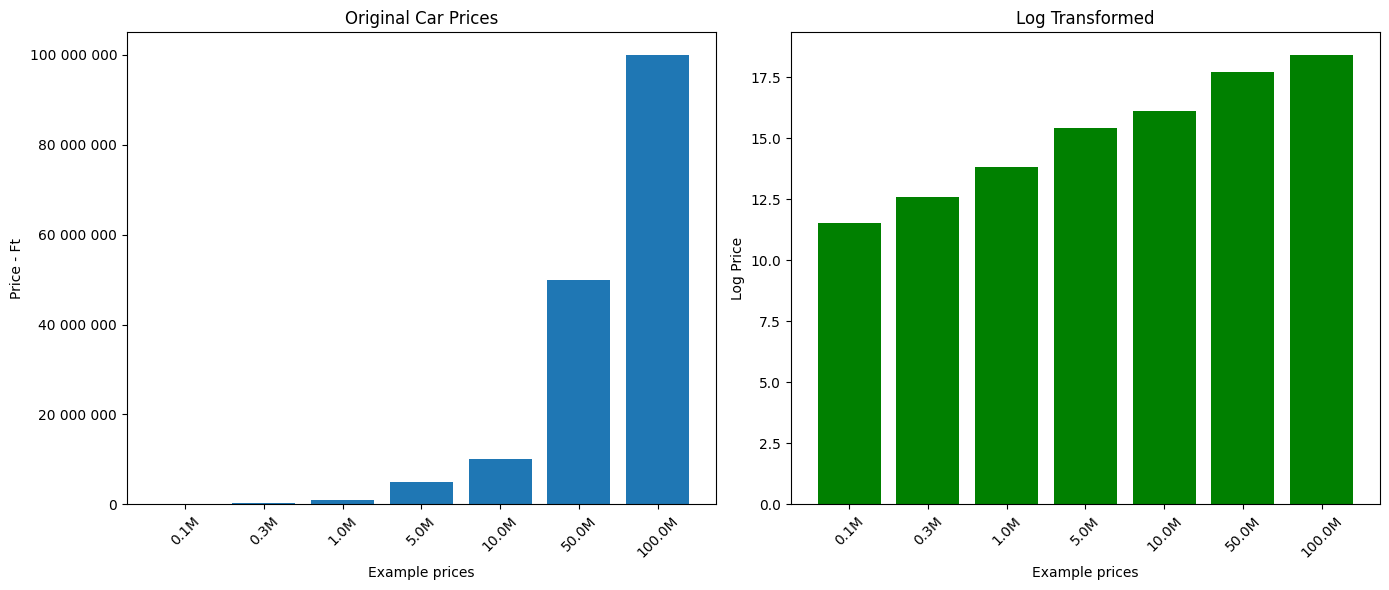

In [6]:
sample_prices = [100_000, 300_000, 1_000_000, 5_000_000, 10_000_000, 50_000_000, 100_000_000]
log_prices = np.log(sample_prices)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.set_title('Original Car Prices')
ax1.set_xlabel('Example prices')
ax1.set_ylabel('Price - Ft')
ax1.bar(range(len(sample_prices)), sample_prices)
ax1.set_xticks(range(len(sample_prices)))
ax1.set_xticklabels([f"{p/1_000_000:.1f}M" for p in sample_prices], rotation=45)
ax1.yaxis.set_major_formatter(lambda x, _: f"{int(x):,}".replace(",", " "))

# Log transformed
ax2.set_title('Log Transformed')
ax2.set_xlabel('Example prices')
ax2.set_ylabel('Log Price')
ax2.bar(range(len(log_prices)), log_prices, color='green')
ax2.set_xticks(range(len(log_prices)))
ax2.set_xticklabels([f"{p/1_000_000:.1f}M" for p in sample_prices], rotation=45)


plt.tight_layout()
plt.show()